# Exploratory Data Analysis — Image Tampering Detection

This notebook is a **scratch space for exploration only** — it is not part of the production pipeline (`src/tampering_detection/`) and is never imported by `train.py`, `evaluate.py`, or `app.py`. It exists to visually sanity-check the dataset and the ELA preprocessing step before/while trusting them in training.

**What this notebook covers:**
1. Setup and dataset path configuration
2. Class balance check (Authentic vs Tampered counts)
3. File extension audit (catches stray files like `Thumbs.db`)
4. Sample image preview — Authentic vs Tampered
5. ELA preview — visually confirm tampered regions look different
6. Image dimension distribution
7. Summary / notes

## 1. Setup

Run this notebook from inside the `notebooks/` folder. The `sys.path.append("../src")` line lets us import the same `preprocessing.py` used by the real training pipeline, so this exploration reflects exactly what the model will see — no duplicated logic.

In [1]:
import os
import sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image

# Make the real project package importable from inside notebooks/
sys.path.append("../src")
from tampering_detection.preprocessing import compute_ela

%matplotlib inline

In [2]:
# Dataset paths — adjust if your data lives somewhere else
DATA_ROOT = Path("../data/casia_v2")
AU_DIR = DATA_ROOT / "Au"
TP_DIR = DATA_ROOT / "Tp"

VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

assert AU_DIR.exists(), f"Missing folder: {AU_DIR}"
assert TP_DIR.exists(), f"Missing folder: {TP_DIR}"
print("Dataset paths OK.")

Dataset paths OK.


## 2. Class Balance Check

Confirms roughly how many Authentic vs Tampered images exist. A large imbalance would matter for training (e.g. would justify class weighting), so it's worth checking once up front rather than assuming the dataset is balanced.

In [3]:
au_files = [f for f in os.listdir(AU_DIR) if f.lower().endswith(VALID_EXT)]
tp_files = [f for f in os.listdir(TP_DIR) if f.lower().endswith(VALID_EXT)]

print(f"Authentic images: {len(au_files)}")
print(f"Tampered images:  {len(tp_files)}")
print(f"Total:            {len(au_files) + len(tp_files)}")
print(f"Class ratio (Au:Tp): {len(au_files) / max(len(tp_files), 1):.2f} : 1")

Authentic images: 7491
Tampered images:  5123
Total:            12614
Class ratio (Au:Tp): 1.46 : 1


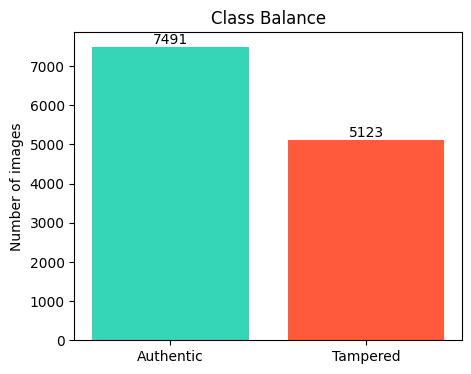

In [4]:
plt.figure(figsize=(5, 4))
plt.bar(["Authentic", "Tampered"], [len(au_files), len(tp_files)],
        color=["#35D6B8", "#FF5A3C"])
plt.title("Class Balance")
plt.ylabel("Number of images")
for i, v in enumerate([len(au_files), len(tp_files)]):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.show()

## 3. File Extension Audit

This is exactly the check that would have caught the `Thumbs.db` issue encountered earlier in the project — a non-image file sitting inside the `Au/` folder that crashed training with `PIL.UnidentifiedImageError`. Run this whenever the dataset folder is touched (re-extracted, re-downloaded, browsed in Windows Explorer, etc.), since Explorer silently regenerates `Thumbs.db`.

In [5]:
def audit_extensions(folder):
    all_files = os.listdir(folder)
    ext_counts = Counter(Path(f).suffix.lower() for f in all_files)
    non_image = [f for f in all_files if not f.lower().endswith(VALID_EXT)]
    return ext_counts, non_image

for name, folder in [("Au", AU_DIR), ("Tp", TP_DIR)]:
    ext_counts, non_image = audit_extensions(folder)
    print(f"--- {name}/ ---")
    print("Extension counts:", dict(ext_counts))
    if non_image:
        print(f"WARNING: {len(non_image)} non-image file(s) found: {non_image[:10]}")
    else:
        print("No stray non-image files found. \u2713")
    print()

--- Au/ ---
Extension counts: {'.jpg': 7437, '.bmp': 54}
No stray non-image files found. ✓

--- Tp/ ---
Extension counts: {'.tif': 3059, '.jpg': 2064, '.txt': 1}



## 4. Sample Image Preview

A quick visual look at a handful of raw images from each class, before any preprocessing, just to eyeball that the folders contain what we expect.

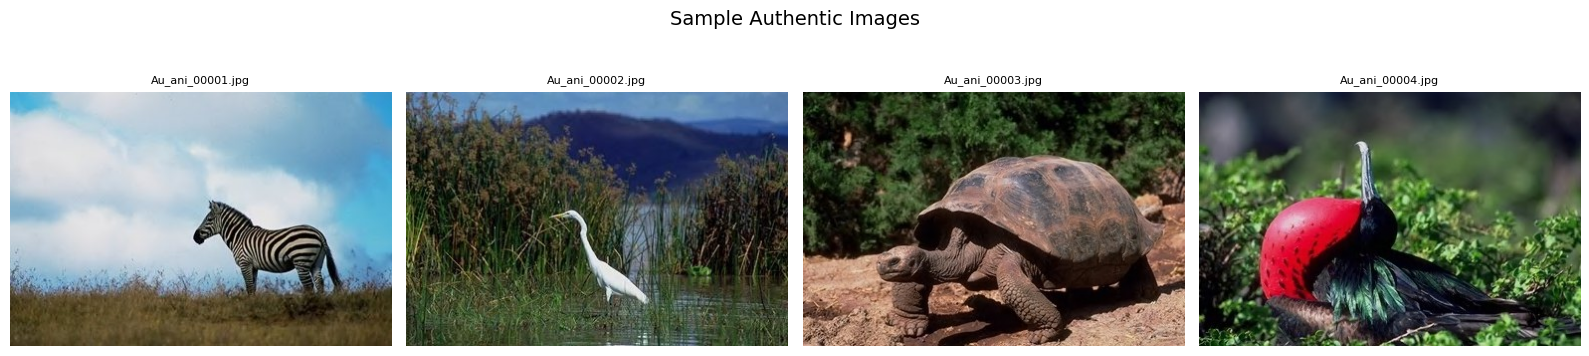

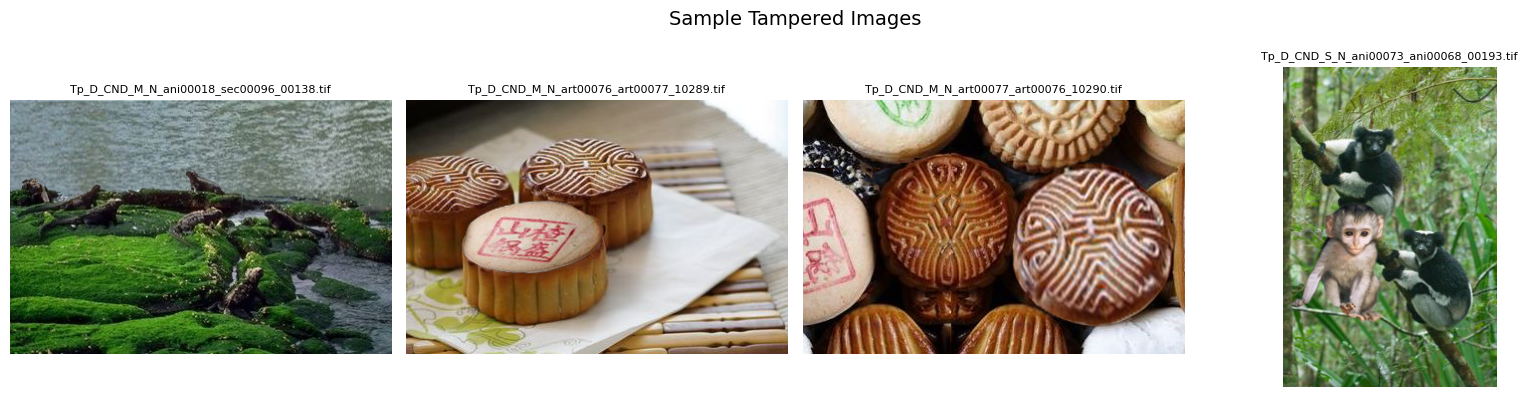

In [6]:
def show_sample_grid(file_list, folder, title, n=4):
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle(title, fontsize=14)
    for ax, fname in zip(axes, file_list[:n]):
        img = Image.open(folder / fname).convert("RGB")
        ax.imshow(img)
        ax.set_title(fname, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_grid(au_files, AU_DIR, "Sample Authentic Images")
show_sample_grid(tp_files, TP_DIR, "Sample Tampered Images")

## 5. ELA Preview — Authentic vs Tampered

This is the most important visual check in this notebook. It calls the **exact same `compute_ela()` function** used by `dataset.py` during training, so what you see here is precisely the ELA representation the model actually learns from — not an approximation.

**What to look for:** tampered images often show a brighter / noisier patch in the ELA output over the manipulated region, while authentic images tend to show a more uniform, low-intensity ELA pattern across the whole image. If tampered samples don't show any visible difference, that's a signal the preprocessing or dataset may need attention before trusting training results.

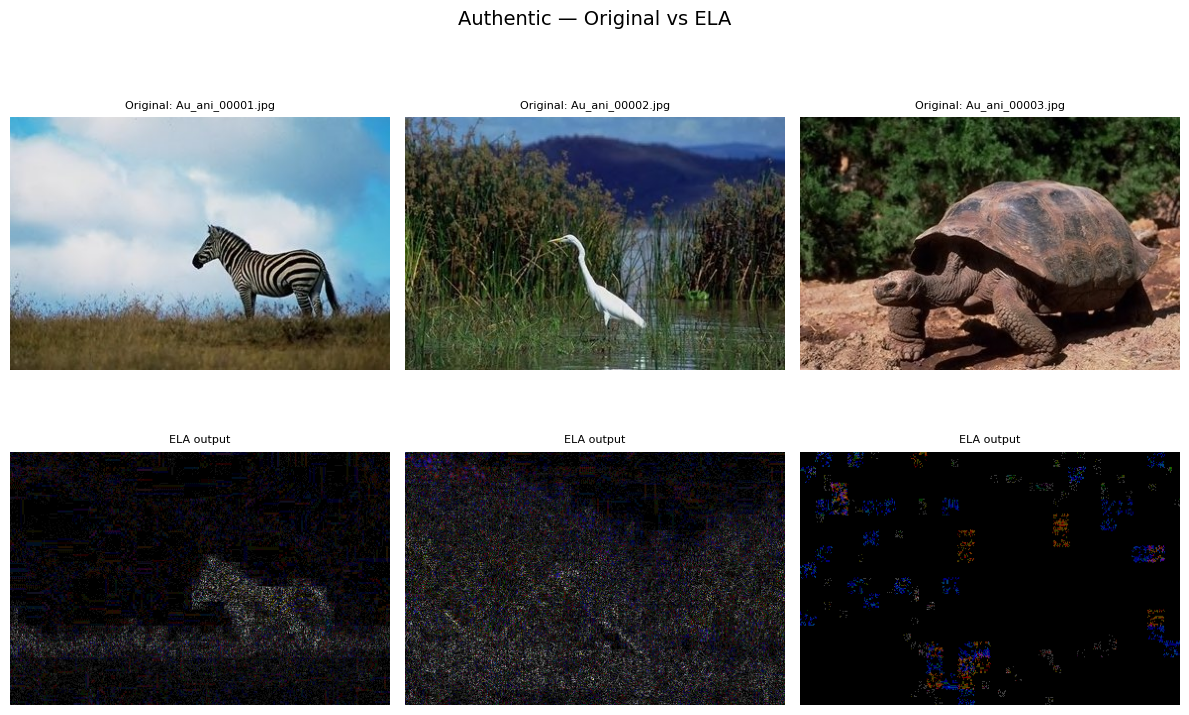

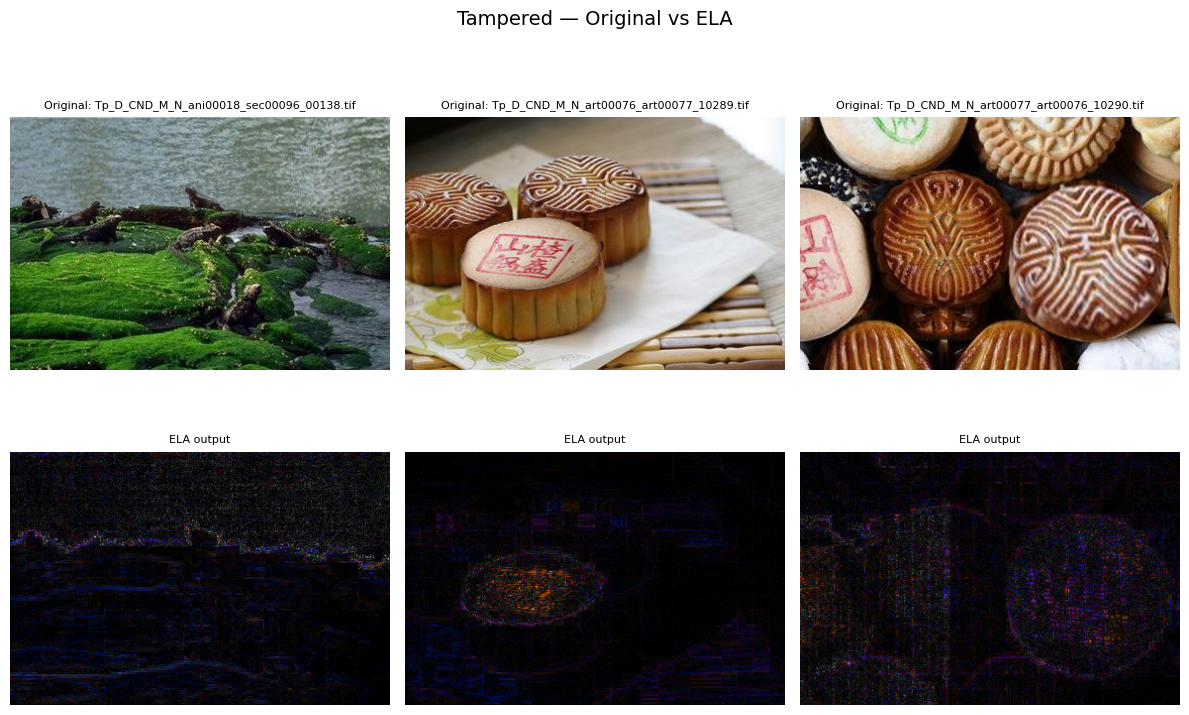

In [7]:
def show_ela_comparison(file_list, folder, title, n=3, quality=90):
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    fig.suptitle(title, fontsize=14)
    for i, fname in enumerate(file_list[:n]):
        path = folder / fname
        original = Image.open(path).convert("RGB")
        ela_img = compute_ela(str(path), quality=quality)

        axes[0, i].imshow(original)
        axes[0, i].set_title(f"Original: {fname}", fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(ela_img)
        axes[1, i].set_title("ELA output", fontsize=8)
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()

show_ela_comparison(au_files, AU_DIR, "Authentic — Original vs ELA")
show_ela_comparison(tp_files, TP_DIR, "Tampered — Original vs ELA")

### 5.2 Saving a Figure for the Project Report

The cell above only *displays* the ELA comparison inline — it does not save anything to disk. The cell below saves one ELA comparison figure to `results/figures/`, which is the same folder referenced by the project report's Fig. 4.5 / Fig. 7.2 placeholders. Run this once you're happy with how a comparison looks, to produce a real image you can paste into the report instead of leaving the caption unillustrated.

Saved: ..\results\figures\tampered_ela_comparison.png


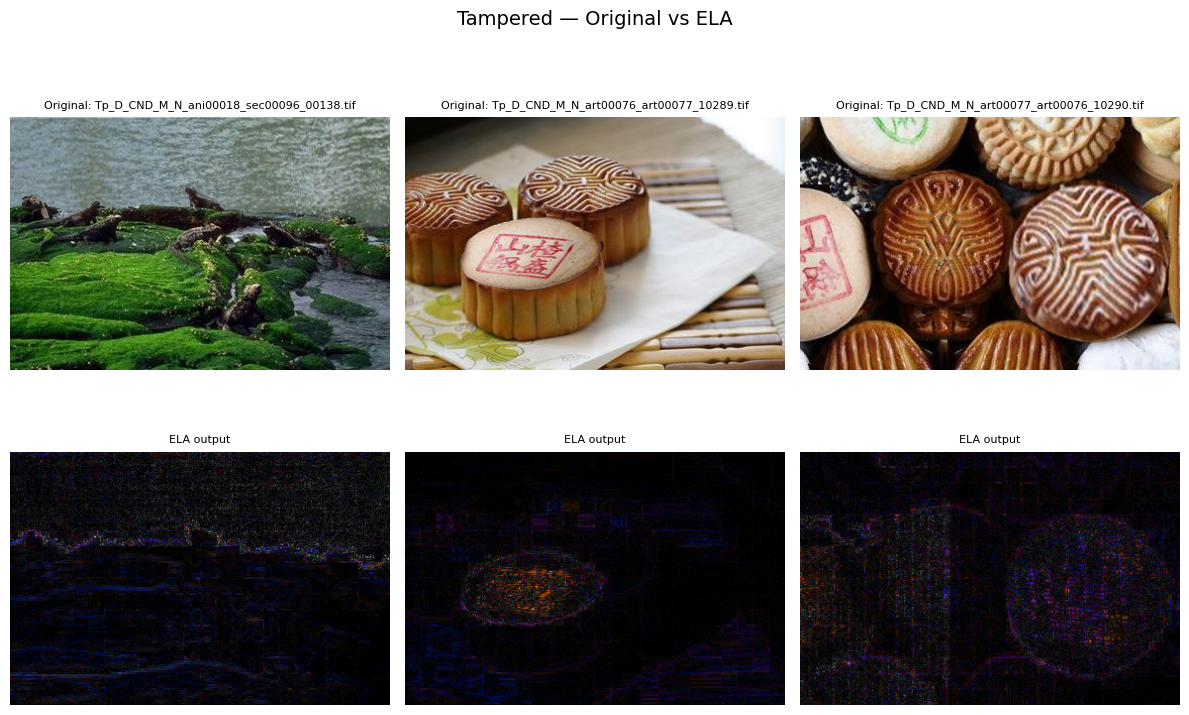

Saved: ..\results\figures\authentic_ela_comparison.png


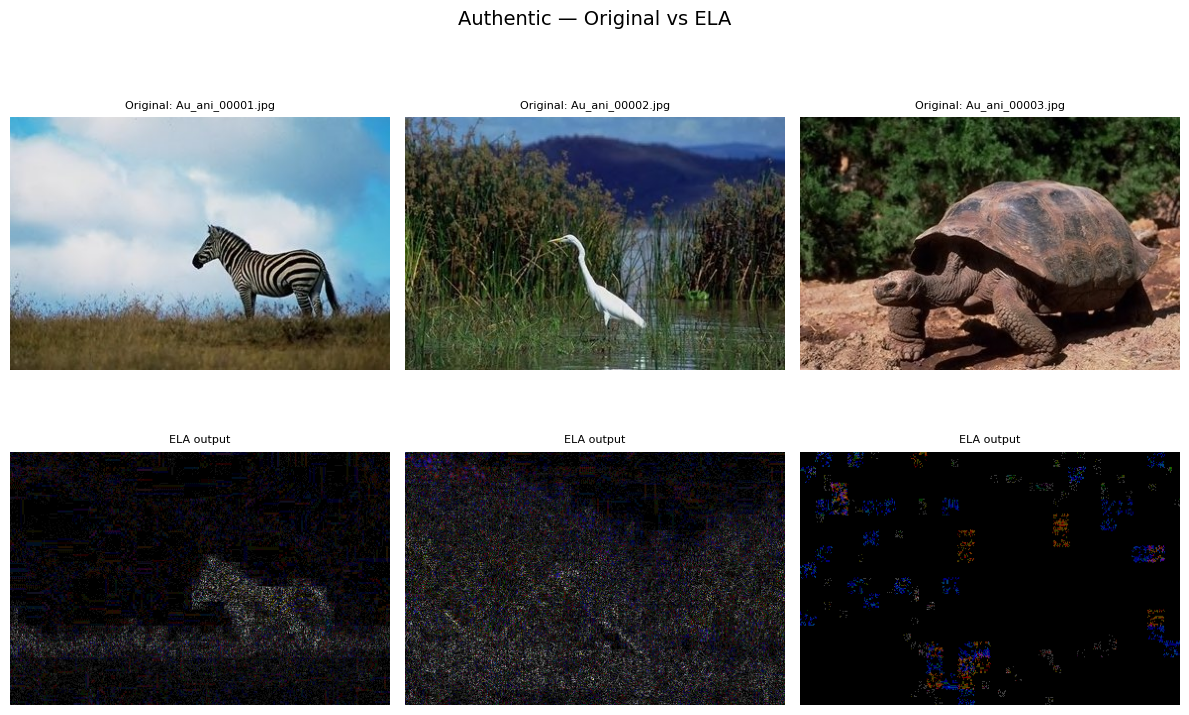

In [8]:
import os

FIGURES_DIR = Path("../results/figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_ela_comparison(file_list, folder, title, save_name, n=3, quality=90):
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    fig.suptitle(title, fontsize=14)
    for i, fname in enumerate(file_list[:n]):
        path = folder / fname
        original = Image.open(path).convert("RGB")
        ela_img = compute_ela(str(path), quality=quality)

        axes[0, i].imshow(original)
        axes[0, i].set_title(f"Original: {fname}", fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(ela_img)
        axes[1, i].set_title("ELA output", fontsize=8)
        axes[1, i].axis("off")
    plt.tight_layout()

    save_path = FIGURES_DIR / save_name
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

save_ela_comparison(tp_files, TP_DIR, "Tampered — Original vs ELA", "tampered_ela_comparison.png")
save_ela_comparison(au_files, AU_DIR, "Authentic — Original vs ELA", "authentic_ela_comparison.png")

### 5.1 Effect of JPEG Quality on ELA

`compute_ela()` re-compresses at a configurable quality level (90 is the default used in `dataset.py`). It's worth checking a couple of alternative quality values on the *same* image to build intuition for how sensitive the ELA output is to this parameter — useful context if you ever tune it.

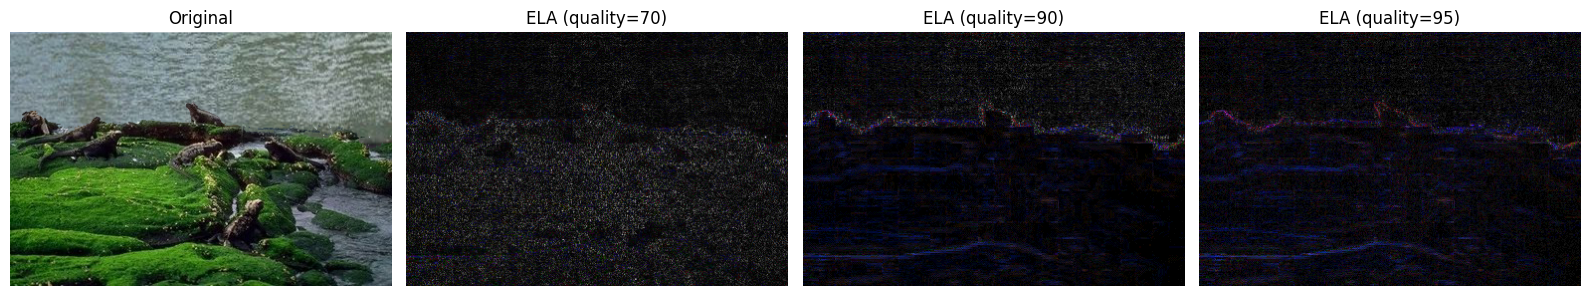

In [9]:
sample_path = TP_DIR / tp_files[0]
qualities = [70, 90, 95]

fig, axes = plt.subplots(1, len(qualities) + 1, figsize=(4 * (len(qualities) + 1), 4))
axes[0].imshow(Image.open(sample_path).convert("RGB"))
axes[0].set_title("Original")
axes[0].axis("off")

for ax, q in zip(axes[1:], qualities):
    ax.imshow(compute_ela(str(sample_path), quality=q))
    ax.set_title(f"ELA (quality={q})")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Image Dimension Distribution

The model resizes every image to 128×128 regardless of its original size, so this is purely informational — but it's useful to know how much resizing/distortion is actually happening, and whether the two classes differ systematically in size (which could otherwise become an unintended shortcut the model learns instead of real tampering cues).

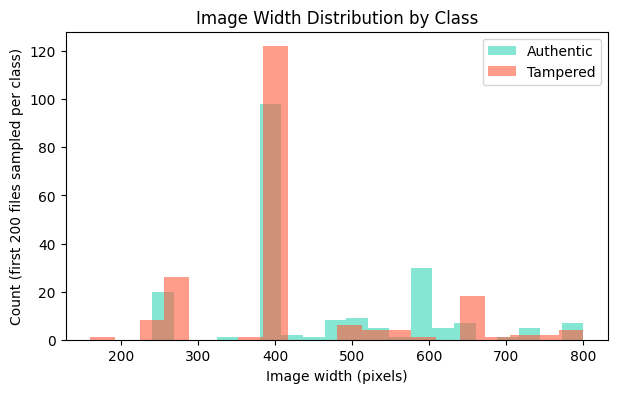

In [10]:
def get_dimensions(file_list, folder, sample_size=200):
    dims = []
    for fname in file_list[:sample_size]:
        with Image.open(folder / fname) as img:
            dims.append(img.size)  # (width, height)
    return dims

au_dims = get_dimensions(au_files, AU_DIR)
tp_dims = get_dimensions(tp_files, TP_DIR)

au_widths = [w for w, h in au_dims]
tp_widths = [w for w, h in tp_dims]

plt.figure(figsize=(7, 4))
plt.hist(au_widths, bins=20, alpha=0.6, label="Authentic", color="#35D6B8")
plt.hist(tp_widths, bins=20, alpha=0.6, label="Tampered", color="#FF5A3C")
plt.xlabel("Image width (pixels)")
plt.ylabel("Count (first 200 files sampled per class)")
plt.title("Image Width Distribution by Class")
plt.legend()
plt.show()

## 7. Summary / Notes

Use this cell to jot down observations from each exploration pass — e.g. whether class balance looks reasonable, whether ELA visibly separates the two classes, or whether any data-quality issues were found. Keeping notes here (rather than only in your head) makes it easier to remember *why* a preprocessing or dataset decision was made later on.